# 04 — Model Evaluation & Comparison

Automatically scans all trained models in `experiment_model/models/`, extracts
evaluation metrics, and generates group-based comparison reports and visualizations.

**Model folder naming convention:** `{learningrate}_{batchsize}_{inputtype}_{modeltype}`  
**Example:** `-3_16_processed_lstm`

---

## Notebook Sections
1. Import Libraries  
2. Configuration & Paths  
3. Load & Parse Model Metadata  
4. Data Overview  
5. Group-Based Analysis & Visualization  
   - 5.1 By Learning Rate  
   - 5.2 By Batch Size  
   - 5.3 By Input Type  
   - 5.4 By Model Type  
6. Category Rankings  
7. Global Top-5 Rankings  
8. Summary & Conclusions  

## 1. Import Libraries

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Configuration & Paths

All path and constant definitions live here — edit this cell to adapt to a
different directory layout.

In [2]:
NOTEBOOK_DIR = Path().resolve()
BASE_DIR     = NOTEBOOK_DIR.parent
MODELS_DIR   = BASE_DIR / 'models'
LOGS_DIR     = BASE_DIR / 'logs' / 'training'

METRICS = ['acc', 'val_acc', 'recall', 'f1_score']

METRIC_LABELS = {
    'acc':      'Accuracy (Test)',
    'val_acc':  'Validation Accuracy',
    'recall':   'Recall',
    'f1_score': 'F1 Score',
}

CATEGORY_LABELS = {
    'learningrate': 'Learning Rate',
    'batchsize':    'Batch Size',
    'inputtype':    'Input Type',
    'modeltype':    'Model Type',
}

print(f'Base directory  : {BASE_DIR}')
print(f'Models directory: {MODELS_DIR}')
print(f'Logs directory  : {LOGS_DIR}')

if MODELS_DIR.exists():
    n_dirs = sum(1 for p in MODELS_DIR.iterdir() if p.is_dir())
    print(f'Model folders found: {n_dirs}')
else:
    print('WARNING: Models directory not found!')

Base directory  : C:\Users\Napat\termtemsl\experiment_model
Models directory: C:\Users\Napat\termtemsl\experiment_model\models
Logs directory  : C:\Users\Napat\termtemsl\experiment_model\logs\training
Model folders found: 91


## 3. Load & Parse Model Metadata

**Metric sources (in priority order):**
- `acc`, `recall`, `f1_score` ← `metrics.json` (test-set evaluation)
- `val_acc` ← `analysis_summary.json` (`underfitting.best_val_acc`)
- `val_acc` fallback ← `logs/training/{exp}.json` (Keras training history)

Missing files are handled gracefully; models with no loadable metrics are skipped.

In [4]:
def parse_folder_name(name: str) -> dict | None:
    '''Parse experiment folder name into its four components.

    Convention : {lr_exp}_{batch_size}_{input_type}_{model_type}
    Example    : -3_8_processed_lstm
    Returns None if the name does not match the expected structure.
    '''
    parts = name.split('_')
    if len(parts) < 4:
        return None
    lr        = parts[0]
    batchsize = parts[1]
    modeltype = parts[-1]
    inputtype = '_'.join(parts[2:-1])
    try:
        batchsize = int(batchsize)
    except ValueError:
        return None
    return {
        'learningrate': lr,
        'batchsize':    batchsize,
        'inputtype':    inputtype,
        'modeltype':    modeltype,
    }


def load_model_data(model_dir: Path) -> dict:
    '''Load evaluation metrics for a single model directory.

    Returns a (possibly partial) dict with keys: acc, val_acc, recall, f1_score.
    Missing values are left as NaN via pd.NA downstream.
    '''
    data = {}

    metrics_path = model_dir / 'metrics.json'
    if metrics_path.exists():
        try:
            with open(metrics_path) as f:
                m = json.load(f)
            data['acc']      = m.get('accuracy')
            data['recall']   = m.get('macro_recall')
            data['f1_score'] = m.get('macro_f1')
        except Exception:
            pass

    summary_path = model_dir / 'analysis_summary.json'
    if summary_path.exists():
        try:
            with open(summary_path) as f:
                s = json.load(f)
            for section in ('underfitting', 'overfitting'):
                val = s.get(section, {}).get('best_val_acc')
                if val is not None:
                    data['val_acc'] = val
                    break
        except Exception:
            pass

    if data.get('val_acc') is None:
        log_path = LOGS_DIR / f'{model_dir.name}.json'
        if log_path.exists():
            try:
                with open(log_path) as f:
                    log = json.load(f)
                history = log.get('history', {})
                for key in ('val_accuracy', 'val_acc'):
                    if key in history and history[key]:
                        data['val_acc'] = max(history[key])
                        break
                if data.get('val_acc') is None:
                    for key in ('best_val_accuracy', 'best_val_acc'):
                        v = log.get(key)
                        if v is not None:
                            data['val_acc'] = v
                            break
            except Exception:
                pass

    return data


records = []
skipped = []

if not MODELS_DIR.exists():
    print(f'ERROR: Models directory not found at {MODELS_DIR}')
else:
    for model_dir in sorted(MODELS_DIR.iterdir()):
        if not model_dir.is_dir():
            continue

        parsed = parse_folder_name(model_dir.name)
        if parsed is None:
            skipped.append(model_dir.name)
            continue

        metrics = load_model_data(model_dir)
        if not metrics:
            skipped.append(model_dir.name)
            continue

        records.append({'model': model_dir.name, **parsed, **metrics})

df = pd.DataFrame(records)

for col in METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Models loaded : {len(df)}')
if skipped:
    preview = skipped[:5]
    more    = f'... (+{len(skipped) - 5} more)' if len(skipped) > 5 else ''
    print(f'Skipped ({len(skipped)}): {preview} {more}')

Models loaded : 91


## 4. Data Overview

Quick sanity check on the loaded data before analysis.

In [5]:
print(f'DataFrame shape : {df.shape}')
print(f'\nUnique values per grouping category:')
for col, label in CATEGORY_LABELS.items():
    if col in df.columns:
        vals = sorted(df[col].unique().tolist(), key=lambda x: (str(type(x)), x))
        print(f'  {label:20s}: {vals}')

print(f'\nMetric coverage (non-null counts out of {len(df)}):')
for col in METRICS:
    if col in df.columns:
        n = df[col].notna().sum()
        pct = 100 * n / len(df)
        print(f'  {METRIC_LABELS[col]:25s}: {n}/{len(df)} ({pct:.0f}%)')

print(f'\nDescriptive statistics:')
display(df[METRICS].describe().round(4))

DataFrame shape : (91, 9)

Unique values per grouping category:
  Learning Rate       : ['-3', '-4', '-5', '-6', '-7']
  Batch Size          : [8, 16, 32]
  Input Type          : ['cutting', 'oldprocessed', 'processed']
  Model Type          : ['gru', 'lstm', 'rnn']

Metric coverage (non-null counts out of 91):
  Accuracy (Test)          : 91/91 (100%)
  Validation Accuracy      : 91/91 (100%)
  Recall                   : 91/91 (100%)
  F1 Score                 : 91/91 (100%)

Descriptive statistics:


,acc,val_acc,recall,f1_score
count,91.0000,91.0000,91.0000,91.0000
mean,0.1271,0.1271,0.1271,0.0597
std,0.0454,0.0454,0.0454,0.0426
min,0.0750,0.0750,0.0750,0.0183
25%,0.1000,0.1000,0.1000,0.0347
50%,0.1138,0.1138,0.1138,0.0481
75%,0.1375,0.1375,0.1375,0.0742
max,0.3276,0.3276,0.3276,0.2478


In [6]:
display(
    df[['model', 'learningrate', 'batchsize', 'inputtype', 'modeltype'] + METRICS]
    .head(10)
    .style.format({m: '{:.4f}' for m in METRICS}, na_rep='N/A')
    .set_caption('Sample of loaded model data')
)

,model,learningrate,batchsize,inputtype,modeltype,acc,val_acc,recall,f1_score
0,-3_16_oldprocessed_gru,-3,16,oldprocessed,gru,0.3276,0.3276,0.3276,0.2478
1,-3_16_oldprocessed_lstm,-3,16,oldprocessed,lstm,0.2759,0.2759,0.2759,0.2051
2,-3_16_oldprocessed_rnn,-3,16,oldprocessed,rnn,0.1690,0.1690,0.1690,0.0599
3,-3_16_processed_gru,-3,16,processed,gru,0.1187,0.1187,0.1187,0.0894
4,-3_16_processed_lstm,-3,16,processed,lstm,0.1375,0.1375,0.1375,0.0642
5,-3_16_processed_rnn,-3,16,processed,rnn,0.1562,0.1562,0.1562,0.0859
6,-3_32_oldprocessed_gru,-3,32,oldprocessed,gru,0.1103,0.1103,0.1103,0.0395
7,-3_32_oldprocessed_lstm,-3,32,oldprocessed,lstm,0.2655,0.2655,0.2655,0.1694
8,-3_32_oldprocessed_rnn,-3,32,oldprocessed,rnn,0.1207,0.1207,0.1207,0.0477
9,-3_32_processed_gru,-3,32,processed,gru,0.1437,0.1437,0.1437,0.0794


## Helper Functions

Shared utilities for grouping and plotting — used by all analysis sections below.

In [7]:
COLORS  = sns.color_palette('tab10', n_colors=4)
MARKERS = ['o', 's', '^', 'D']


def compute_group_means(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    '''Return a DataFrame of per-group metric averages.

    Index  = unique values of group_col
    Columns = METRICS (those present in data)
    '''
    available = [m for m in METRICS if m in data.columns]
    return data.groupby(group_col)[available].mean().round(4)


def plot_group_metrics(group_df: pd.DataFrame,
                       x_label:  str,
                       title:    str) -> None:
    '''Line chart comparing all four metrics across groups.

    group_df : result of compute_group_means() — index = group labels
    x_label  : x-axis label (name of the grouping category)
    title    : plot title
    '''
    fig, ax = plt.subplots(figsize=(max(8, len(group_df) * 2), 5))

    x_labels = [str(v) for v in group_df.index.tolist()]
    x_pos    = list(range(len(x_labels)))

    for i, metric in enumerate(METRICS):
        if metric not in group_df.columns:
            continue
        values = group_df[metric].tolist()
        ax.plot(x_pos, values,
                marker=MARKERS[i], color=COLORS[i],
                linewidth=2.2, markersize=9,
                label=METRIC_LABELS[metric])
        for j, v in enumerate(values):
            if pd.notna(v):
                ax.annotate(
                    f'{v:.3f}',
                    xy=(x_pos[j], v),
                    textcoords='offset points',
                    xytext=(0, 9),
                    ha='center',
                    fontsize=8.5,
                    color=COLORS[i],
                    fontweight='semibold',
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_xlabel(x_label, fontsize=12, labelpad=8)
    ax.set_ylabel('Average Metric Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.legend(loc='best', framealpha=0.9, edgecolor='#cccccc')
    ax.set_ylim(0, 1.18)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 5. Group-Based Analysis & Visualization

For each grouping category the models are partitioned and their metrics are
averaged within each group. A line chart then shows how each average metric
changes across the groups in that category.

### 5.1  Group by Learning Rate

The `learningrate` column stores the base-10 exponent (e.g., `-3` means 10⁻³).
Groups are ordered from highest exponent (fastest LR) to lowest.

Average metrics grouped by Learning Rate (log₁₀ exponent):


,acc,val_acc,recall,f1_score
learningrate,,,,
-7,0.1074,0.1074,0.1074,0.0395
-6,0.1072,0.1072,0.1072,0.0411
-5,0.1113,0.1113,0.1113,0.0458
-4,0.1274,0.1274,0.1274,0.0614
-3,0.1792,0.1792,0.1792,0.1080


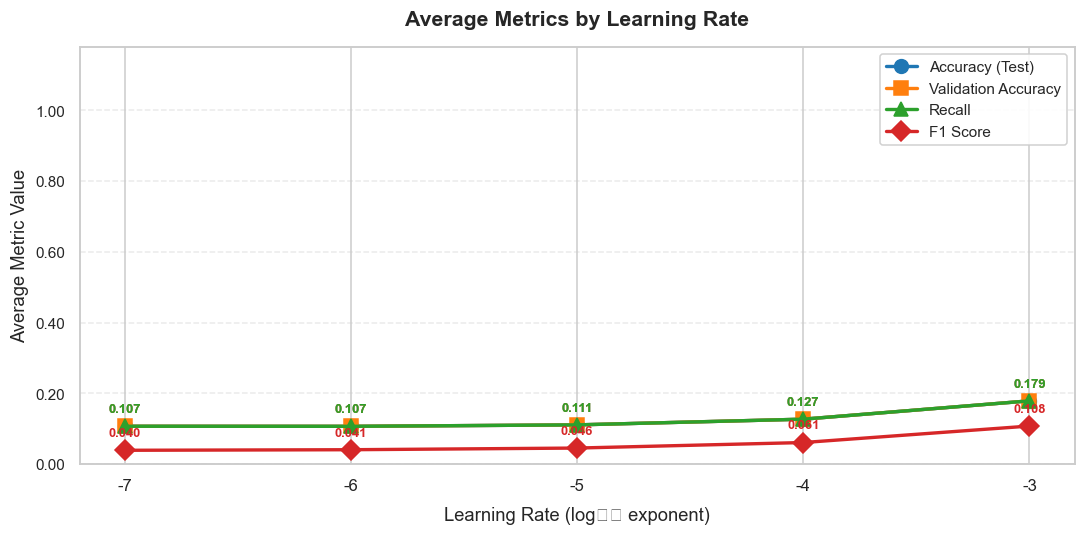

In [8]:
lr_means = compute_group_means(df, 'learningrate')

lr_order = sorted(lr_means.index, key=lambda x: int(x))
lr_means = lr_means.loc[lr_order]

print('Average metrics grouped by Learning Rate (log₁₀ exponent):')
display(
    lr_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    lr_means,
    x_label='Learning Rate (log₁₀ exponent)',
    title='Average Metrics by Learning Rate',
)

### 5.2  Group by Batch Size

Average metrics grouped by Batch Size:


,acc,val_acc,recall,f1_score
batchsize,,,,
8,0.1280,0.1280,0.1280,0.0619
16,0.1324,0.1324,0.1324,0.0648
32,0.1209,0.1209,0.1209,0.0524


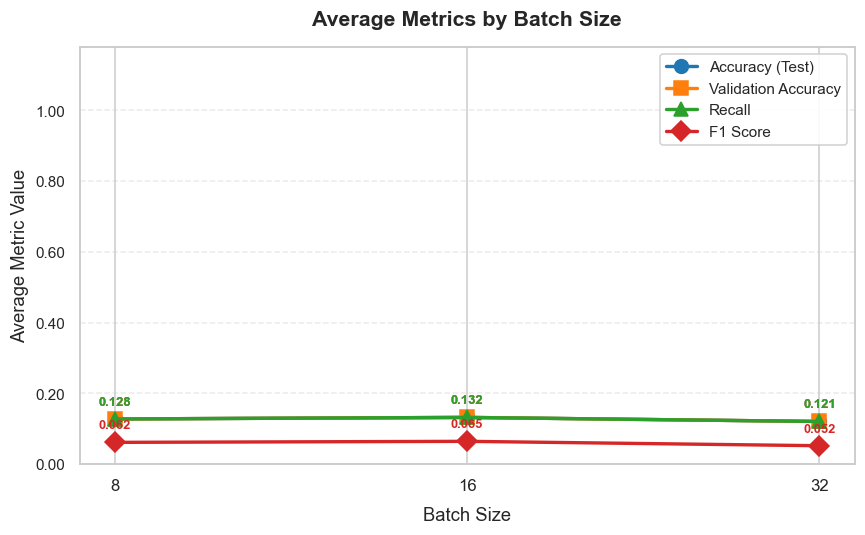

In [9]:
bs_means = compute_group_means(df, 'batchsize').sort_index()

print('Average metrics grouped by Batch Size:')
display(
    bs_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    bs_means,
    x_label='Batch Size',
    title='Average Metrics by Batch Size',
)

### 5.3  Group by Input Type

Average metrics grouped by Input Type:


,acc,val_acc,recall,f1_score
inputtype,,,,
cutting,0.1313,0.1312,0.1313,0.0764
oldprocessed,0.1302,0.1302,0.1302,0.0541
processed,0.1239,0.1239,0.1239,0.0649


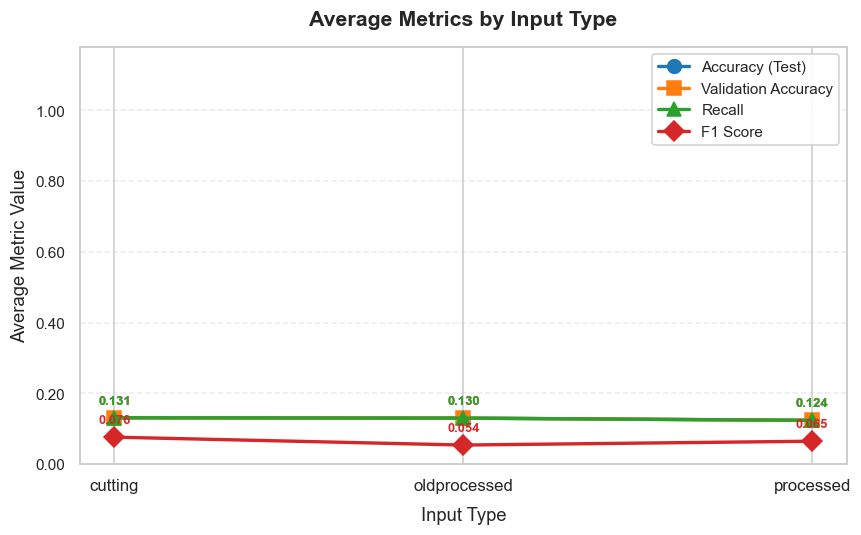

In [10]:
it_means = compute_group_means(df, 'inputtype').sort_index()

print('Average metrics grouped by Input Type:')
display(
    it_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    it_means,
    x_label='Input Type',
    title='Average Metrics by Input Type',
)

### 5.4  Group by Model Type

Average metrics grouped by Model Type:


,acc,val_acc,recall,f1_score
modeltype,,,,
gru,0.1267,0.1267,0.1267,0.0655
lstm,0.1418,0.1418,0.1418,0.0640
rnn,0.1122,0.1122,0.1122,0.0494


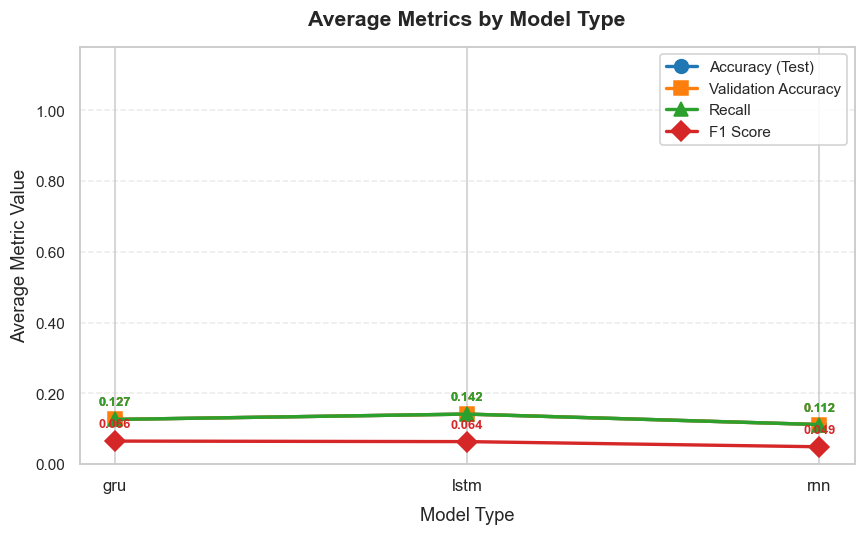

In [11]:
mt_means = compute_group_means(df, 'modeltype').sort_index()

print('Average metrics grouped by Model Type:')
display(
    mt_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    mt_means,
    x_label='Model Type',
    title='Average Metrics by Model Type',
)

## 6. Category Rankings

For each grouping category, rank the options from best to worst for every metric.

In [12]:
def print_category_rankings(data: pd.DataFrame,
                             group_col: str,
                             category_label: str) -> None:
    '''Print ranked options for every metric within one grouping category.'''
    group_means = compute_group_means(data, group_col)

    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  Rankings by {category_label}')
    print(sep)

    for metric, metric_label in METRIC_LABELS.items():
        if metric not in group_means.columns:
            continue
        ranked = (
            group_means[metric]
            .dropna()
            .sort_values(ascending=False)
        )
        if ranked.empty:
            continue
        print(f'\n  Best {category_label} by {metric_label}:')
        for rank, (name, val) in enumerate(ranked.items(), start=1):
            bar = '#' * int(val * 20)  # mini bar for quick visual reference
            print(f'    {rank}. {str(name):20s}  {val:.4f}  {bar}')


for col, label in CATEGORY_LABELS.items():
    if col in df.columns:
        print_category_rankings(df, col, label)


  Rankings by Learning Rate

  Best Learning Rate by Accuracy (Test):
    1. -3                    0.1792  ###
    2. -4                    0.1274  ##
    3. -5                    0.1113  ##
    4. -7                    0.1074  ##
    5. -6                    0.1072  ##

  Best Learning Rate by Validation Accuracy:
    1. -3                    0.1792  ###
    2. -4                    0.1274  ##
    3. -5                    0.1113  ##
    4. -7                    0.1074  ##
    5. -6                    0.1072  ##

  Best Learning Rate by Recall:
    1. -3                    0.1792  ###
    2. -4                    0.1274  ##
    3. -5                    0.1113  ##
    4. -7                    0.1074  ##
    5. -6                    0.1072  ##

  Best Learning Rate by F1 Score:
    1. -3                    0.1080  ##
    2. -4                    0.0614  #
    3. -5                    0.0458  
    4. -6                    0.0411  
    5. -7                    0.0395  

  Rankings by Batc

## 7. Global Top-5 Rankings

Overall rankings across **all individual models** (no grouping) for each metric.

In [13]:
TOP_N = 5

print('=' * 72)
print('  GLOBAL MODEL RANKINGS  (Individual Models — No Grouping)')
print('=' * 72)

for metric, metric_label in METRIC_LABELS.items():
    if metric not in df.columns:
        continue

    top = (
        df[['model', metric]]
        .dropna(subset=[metric])
        .nlargest(TOP_N, metric)
        .reset_index(drop=True)
    )

    print(f'\n  Top {TOP_N} Models by {metric_label}:')
    if top.empty:
        print('    (no data available)')
        continue
    for i, row in top.iterrows():
        print(f'    {i + 1}. {row["model"]:40s}  ({row[metric]:.4f})')

  GLOBAL MODEL RANKINGS  (Individual Models — No Grouping)

  Top 5 Models by Accuracy (Test):
    1. -3_16_oldprocessed_gru                    (0.3276)
    2. -3_8_oldprocessed_gru                     (0.2966)
    3. -3_8_oldprocessed_lstm                    (0.2828)
    4. -3_16_oldprocessed_lstm                   (0.2759)
    5. -3_32_oldprocessed_lstm                   (0.2655)

  Top 5 Models by Validation Accuracy:
    1. -3_16_oldprocessed_gru                    (0.3276)
    2. -3_8_oldprocessed_gru                     (0.2966)
    3. -3_8_oldprocessed_lstm                    (0.2828)
    4. -3_16_oldprocessed_lstm                   (0.2759)
    5. -3_32_oldprocessed_lstm                   (0.2655)

  Top 5 Models by Recall:
    1. -3_16_oldprocessed_gru                    (0.3276)
    2. -3_8_oldprocessed_gru                     (0.2966)
    3. -3_8_oldprocessed_lstm                    (0.2828)
    4. -3_16_oldprocessed_lstm                   (0.2759)
    5. -3_32_oldprocessed_

## 8. Summary & Conclusions

Consolidate the best option per category × metric into a single summary table,
then print readable key takeaways.

In [15]:
rows = []
for col, cat_label in CATEGORY_LABELS.items():
    if col not in df.columns:
        continue
    gm = compute_group_means(df, col)
    for metric, metric_label in METRIC_LABELS.items():
        if metric not in gm.columns or gm[metric].isna().all():
            continue
        best_name = gm[metric].idxmax()
        best_val  = gm[metric].max()
        rows.append({
            'Category':    cat_label,
            'Metric':      metric_label,
            'Best Option': str(best_name),
            'Avg Value':   round(best_val, 4),
        })

summary_df = pd.DataFrame(rows)

print('SUMMARY: Best Option per Category × Metric')
print('=' * 72)
display(
    summary_df.style
    .set_caption('Best-performing configuration for each category and metric')
)

print('\n\nKEY TAKEAWAYS')
print('=' * 72)
for metric, metric_label in METRIC_LABELS.items():
    subset = summary_df[summary_df['Metric'] == metric_label]
    if subset.empty:
        continue
    print(f'\n{metric_label}:')
    for _, row in subset.iterrows():
        print(f'  Best {row["Category"]:20s}: {row["Best Option"]}  ({row["Avg Value"]:.4f})')

SUMMARY: Best Option per Category × Metric


,Category,Metric,Best Option,Avg Value
0,Learning Rate,Accuracy (Test),-3,0.179200
1,Learning Rate,Validation Accuracy,-3,0.179200
2,Learning Rate,Recall,-3,0.179200
3,Learning Rate,F1 Score,-3,0.108000
4,Batch Size,Accuracy (Test),16,0.132400
5,Batch Size,Validation Accuracy,16,0.132400
6,Batch Size,Recall,16,0.132400
7,Batch Size,F1 Score,16,0.064800
8,Input Type,Accuracy (Test),cutting,0.131300
9,Input Type,Validation Accuracy,cutting,0.131200




KEY TAKEAWAYS

Accuracy (Test):
  Best Learning Rate       : -3  (0.1792)
  Best Batch Size          : 16  (0.1324)
  Best Input Type          : cutting  (0.1313)
  Best Model Type          : lstm  (0.1418)

Validation Accuracy:
  Best Learning Rate       : -3  (0.1792)
  Best Batch Size          : 16  (0.1324)
  Best Input Type          : cutting  (0.1312)
  Best Model Type          : lstm  (0.1418)

Recall:
  Best Learning Rate       : -3  (0.1792)
  Best Batch Size          : 16  (0.1324)
  Best Input Type          : cutting  (0.1313)
  Best Model Type          : lstm  (0.1418)

F1 Score:
  Best Learning Rate       : -3  (0.1080)
  Best Batch Size          : 16  (0.0648)
  Best Input Type          : cutting  (0.0764)
  Best Model Type          : gru  (0.0655)


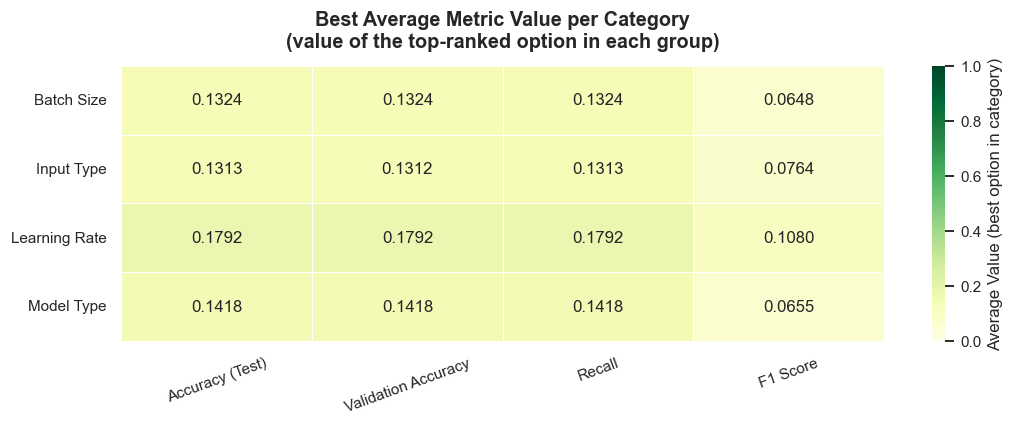

In [16]:
pivot = summary_df.pivot(index='Category', columns='Metric', values='Avg Value')
pivot = pivot[[ml for ml in METRIC_LABELS.values() if ml in pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot.astype(float),
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Average Value (best option in category)'},
    vmin=0,
    vmax=1,
)
ax.set_title(
    'Best Average Metric Value per Category\n(value of the top-ranked option in each group)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()